# Isotropy Gap Reanalysis — HaPPY vs Steane on IBM Fez

## Purpose

Five analyses on existing IBM Fez hardware data (zero QPU cost) to
strengthen the isotropy-gap finding for the Nature paper:

1. **Cross-code isotropy** — side-by-side CV comparison at all stabilizer fractions
2. **Permutation test** — exact p-value for the CV gap
3. **Per-stabilizer DH breakdown** — which stabilizers drive anisotropy in HaPPY
4. **Leave-one-out marginal contributions** — per-stabilizer information content
5. **X-type vs Z-type split** — CSS structure test on Steane

## Data

| Code | Job ID | Circuits | Shots | Date |
|------|--------|----------|-------|------|
| [[5,1,3]] HaPPY | `d6het7m48nic73amv3ag` | 32 (16 err x 2 states) | 8192 | Feb 28 2026 |
| [[7,1,3]] Steane | `d6m0ol0fh9oc73enfa1g` | 44 (22 err x 2 states) | 8192 | Mar 7 2026 |

**Data sources:** HaPPY raw data from `data/happy_553.npz`, Steane from IBM Quantum (live job).

In [1]:
"""Cell 1: Imports & IBM Connection"""

import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install",
                       "qiskit", "qiskit-ibm-runtime", "matplotlib", "numpy", "-q"])

import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
from qiskit_ibm_runtime import QiskitRuntimeService

%matplotlib inline

SHOTS = 8192
SEED = 42
np.random.seed(SEED)

IBM_TOKEN = "5GI3W65AZds2mLbWCaXyjr59CjZSFTBdfR8XJJsEywS8"
service = QiskitRuntimeService(
    channel="ibm_quantum_platform", token=IBM_TOKEN, instance="open-instance"
)

JOB_HAPPY  = "d6het7m48nic73amv3ag"
JOB_STEANE = "d6m0ol0fh9oc73enfa1g"

print("Connected to IBM Quantum")

qiskit_runtime_service._discover_account:WARNING:2026-03-07 12:45:57,081: Loading account with the given token. A saved account will not be used.


Connected to IBM Quantum


In [2]:
"""Cell 2: Code Definitions"""

# ---------- HaPPY [[5,1,3]] ----------
HAPPY_STABS = ["XZZXI", "IXZZX", "XIXZZ", "ZXIXZ"]
HAPPY_N_DATA, HAPPY_N_ANC = 5, 4

errors_happy, labels_happy = ["IIIII"], ["I"]
for q in range(5):
    for p in "XYZ":
        e = list("IIIII"); e[q] = p
        errors_happy.append("".join(e))
        labels_happy.append(f"{p}{q}")
HAPPY_N_HYP = len(errors_happy)  # 16

# ---------- Steane [[7,1,3]] ----------
STEANE_STABS = ["IIIXXXX", "IXXIIXX", "XIXIXIX",
                "IIIZZZZ", "IZZIIZZ", "ZIZIZIZ"]
STEANE_N_DATA, STEANE_N_ANC = 7, 6
STEANE_TYPES = ["X", "X", "X", "Z", "Z", "Z"]

errors_steane, labels_steane = ["IIIIIII"], ["I"]
for q in range(7):
    for p in "XYZ":
        e = list("IIIIIII"); e[q] = p
        errors_steane.append("".join(e))
        labels_steane.append(f"{p}{q}")
STEANE_N_HYP = len(errors_steane)  # 22

print(f"HaPPY:  {HAPPY_N_HYP} hypotheses, {HAPPY_N_ANC} stabilizers")
print(f"Steane: {STEANE_N_HYP} hypotheses, {STEANE_N_ANC} stabilizers")

HaPPY:  16 hypotheses, 4 stabilizers
Steane: 22 hypotheses, 6 stabilizers


In [ ]:
"""Cell 3: Load Hardware Data

HaPPY [[5,1,3]]: loaded from saved raw data (data/happy_553.npz).
Steane [[7,1,3]]: loaded from IBM Quantum (live job).
"""

import os

def extract_bitstrings(pub_result, register_name):
    data = getattr(pub_result.data, register_name)
    bitstrings = data.get_bitstrings()
    return np.array([[int(b) for b in s[::-1]] for s in bitstrings], dtype=int)

def load_job(job_id, circuit_labels):
    job = service.job(job_id)
    result = job.result()
    hw_data = {}
    for i, label in enumerate(circuit_labels):
        hw_data[label] = {
            "syndrome": extract_bitstrings(result[i], "syn"),
            "data":     extract_bitstrings(result[i], "out"),
        }
    return hw_data

def make_circuit_labels(labels):
    return [f"L{s}_{l}" for s in [0, 1] for l in labels]

# --- Load HaPPY from saved .npz ---
print("Loading HaPPY [[5,1,3]] from data/happy_553.npz...")
npz_path = os.path.join(os.path.dirname(os.getcwd()), "data", "happy_553.npz")
if not os.path.exists(npz_path):
    npz_path = os.path.join(os.getcwd(), "data", "happy_553.npz")
raw = np.load(npz_path)
circuit_labels_happy = make_circuit_labels(labels_happy)
hw_happy = {}
for i, label in enumerate(circuit_labels_happy):
    hw_happy[label] = {
        "syndrome": raw[f"pub{i}_syn"].astype(int),
        "data":     raw[f"pub{i}_out"].astype(int),
    }
print(f"  {len(hw_happy)} circuits, syndrome {hw_happy['L0_I']['syndrome'].shape}")

# --- Load Steane from IBM ---
print("Loading Steane [[7,1,3]] from IBM Quantum...")
hw_steane = load_job(JOB_STEANE, make_circuit_labels(labels_steane))
print(f"  {len(hw_steane)} circuits, syndrome {hw_steane['L0_I']['syndrome'].shape}")

In [ ]:
"""Cell 4: Shared DeltaH Computation

Identical to both source notebooks:
- Depolarizing backward boundary (p_no_err=0.7)
- Empirical P(syndrome | error) from training half
- 2-fold cross-validation
- DeltaH = H[p_fwd] - H[p_DBCI]
"""

def entropy_bits(p):
    p = np.asarray(p, dtype=np.float64)
    p = p[p > 0]
    return -np.sum(p * np.log2(p)) if len(p) > 0 else 0.0

def normalize_logits(logits):
    logits = np.asarray(logits, dtype=np.float64)
    logits = logits - np.max(logits)
    probs = np.exp(logits)
    Z = np.sum(probs)
    return probs / Z if Z > 1e-300 else np.ones_like(probs) / len(probs)

def compute_delta_H(hw_data_in, labels, n_hyp, n_anc,
                    p_no_err=0.7, stab_subset=None):
    """Compute DeltaH using a stabilizer subset (or all if None)."""
    if stab_subset is None:
        stab_subset = list(range(n_anc))
    n_sub = len(stab_subset)
    n_syn_space = 2 ** n_sub

    log_prior = np.zeros(n_hyp)
    log_prior[0] = np.log(p_no_err)
    log_prior[1:] = np.log((1 - p_no_err) / (n_hyp - 1))
    log_uniform = np.zeros(n_hyp)
    powers = 2 ** np.arange(n_sub - 1, -1, -1)

    all_dH = []
    for state in ["0", "1"]:
        state_data = {}
        for idx, lbl in enumerate(labels):
            key = f"L{state}_{lbl}"
            if key in hw_data_in:
                state_data[idx] = hw_data_in[key]["syndrome"][:, stab_subset]
        if not state_data:
            continue

        n_shots = len(list(state_data.values())[0])
        mid = n_shots // 2

        for test_sl, train_sl in [(slice(0, mid), slice(mid, None)),
                                   (slice(mid, None), slice(0, mid))]:
            log_lik = np.full((n_hyp, n_syn_space), np.log(1.0 / n_syn_space))
            for h in state_data:
                keys = (state_data[h][train_sl] * powers).sum(axis=1)
                counts = np.zeros(n_syn_space)
                for k in keys:
                    counts[k] += 1
                dist = (counts + 1) / (counts.sum() + n_syn_space)
                log_lik[h] = np.log(dist)

            for h in state_data:
                test_keys = (state_data[h][test_sl] * powers).sum(axis=1)
                for sk in test_keys:
                    p_fwd  = normalize_logits(log_lik[:, sk] + log_uniform)
                    p_dbci = normalize_logits(log_lik[:, sk] + log_prior)
                    all_dH.append(entropy_bits(p_fwd) - entropy_bits(p_dbci))

    return np.mean(all_dH), np.std(all_dH) / np.sqrt(len(all_dH))

# Compute from raw data
dH_happy_full, sem_h = compute_delta_H(hw_happy, labels_happy, HAPPY_N_HYP, HAPPY_N_ANC)
print(f"HaPPY  DeltaH = {dH_happy_full:.4f} +/- {sem_h:.4f} bits  (from data/happy_553.npz)")

dH_steane_full, sem_s = compute_delta_H(hw_steane, labels_steane, STEANE_N_HYP, STEANE_N_ANC)
print(f"Steane DeltaH = {dH_steane_full:.4f} +/- {sem_s:.4f} bits  (from IBM Quantum)")
print(f"Ratio: {dH_steane_full / dH_happy_full:.2f}x")

In [ ]:
"""Cell 5: Analysis 1 -- Full Isotropy Comparison

Compute DeltaH for every C(n,k) stabilizer subset on both codes.
Compare CV (coefficient of variation) at each stabilizer fraction.
"""

def isotropy_analysis(hw_data, labels, n_hyp, n_anc, code_name):
    results = {}
    for k in range(1, n_anc + 1):
        subs = list(combinations(range(n_anc), k))
        vals = []
        for sub in subs:
            dH, _ = compute_delta_H(hw_data, labels, n_hyp, n_anc,
                                    stab_subset=list(sub))
            vals.append(dH)
        mean = np.mean(vals)
        std = np.std(vals, ddof=0)
        cv = std / mean if mean > 0 else 0
        results[k] = {
            'mean': mean, 'std': std, 'cv': cv,
            'min': np.min(vals), 'max': np.max(vals),
            'vals': vals, 'subsets': subs, 'frac': k / n_anc
        }
        print(f"  {code_name} k={k}/{n_anc} ({k/n_anc:.0%}): "
              f"mean={mean:.4f}, CV={cv:.1%}, range=[{np.min(vals):.4f}, {np.max(vals):.4f}]")
    return results

print("--- HaPPY [[5,1,3]] ---")
iso_happy = isotropy_analysis(hw_happy, labels_happy, HAPPY_N_HYP, HAPPY_N_ANC, "HaPPY")

print("\n--- Steane [[7,1,3]] ---")
iso_steane = isotropy_analysis(hw_steane, labels_steane, STEANE_N_HYP, STEANE_N_ANC, "Steane")

# Matched-fraction comparison table
print(f"\n{'='*60}")
print(f"{'Fraction':>10} {'HaPPY k':>8} {'HaPPY CV':>10} {'Steane k':>9} {'Steane CV':>11} {'Gap':>6}")
print(f"{'-'*60}")
match_pairs = [(1, 2, "25/33%"), (2, 3, "50%"), (3, 5, "75/83%")]
for kh, ks, frac_label in match_pairs:
    cvh = iso_happy[kh]['cv']
    cvs = iso_steane[ks]['cv']
    gap = cvh / cvs if cvs > 0 else float('inf')
    print(f"{frac_label:>10} {kh:>5}/{HAPPY_N_ANC} {cvh:>9.1%} {ks:>6}/{STEANE_N_ANC} {cvs:>10.1%} {gap:>5.0f}x")

In [12]:
"""Cell 6: Analysis 2 — Permutation Test

Null hypothesis: the CV difference between HaPPY and Steane is
due to chance (both codes have the same underlying CV).

Key: normalize DeltaH values by each code's full DeltaH before pooling,
so both codes are on the same scale (fraction of full information).
Without normalization, pooling values on different absolute scales
(HaPPY ~1.3 vs Steane ~2.2) produces spurious CV from scale mixing.
"""

def cv(x):
    return np.std(x, ddof=0) / np.mean(x) if np.mean(x) > 0 else 0

# Normalize: divide each code's subset DeltaH values by its full DeltaH
# This puts both on a "fraction of total information" scale
def get_normalized_vals(iso_dict, k, full_dH):
    return np.array(iso_dict[k]['vals']) / full_dH

def exact_permutation_test(vals_a, vals_b, label=""):
    """Exact permutation test on CV difference."""
    observed = cv(vals_a) - cv(vals_b)
    pooled = np.concatenate([vals_a, vals_b])
    n_a = len(vals_a)
    n_total = len(pooled)

    count_ge = 0
    n_perms = 0
    for combo in combinations(range(n_total), n_a):
        perm_a = pooled[list(combo)]
        perm_b = pooled[[i for i in range(n_total) if i not in combo]]
        if cv(perm_a) - cv(perm_b) >= observed:
            count_ge += 1
        n_perms += 1

    p_val = count_ge / n_perms
    print(f"  {label}")
    print(f"    Observed CV gap: {observed:.4f} ({cv(vals_a):.4f} vs {cv(vals_b):.4f})")
    print(f"    Permutations: {n_perms} (exact)")
    print(f"    p-value = {p_val:.4f}  {'***' if p_val<0.001 else '**' if p_val<0.01 else '*' if p_val<0.05 else 'ns'}")
    return p_val

def mc_permutation_test(vals_a, vals_b, n_mc=100_000, label=""):
    """Monte Carlo permutation test for large pools."""
    observed = cv(vals_a) - cv(vals_b)
    pooled = np.concatenate([vals_a, vals_b])
    n_a = len(vals_a)
    count_ge = 0
    for _ in range(n_mc):
        perm = np.random.permutation(pooled)
        if cv(perm[:n_a]) - cv(perm[n_a:]) >= observed:
            count_ge += 1
    p_val = count_ge / n_mc
    print(f"  {label}")
    print(f"    Observed CV gap: {observed:.4f} ({cv(vals_a):.4f} vs {cv(vals_b):.4f})")
    print(f"    MC samples: {n_mc}")
    print(f"    p-value = {p_val:.5f}  {'***' if p_val<0.001 else '**' if p_val<0.01 else '*' if p_val<0.05 else 'ns'}")
    return p_val

print("=== Permutation Tests on CV Gap (normalized by full DeltaH) ===")
print()

# Test 1: Matched ~75-83% (HaPPY k=3 vs Steane k=5)
vals_h3 = get_normalized_vals(iso_happy, 3, dH_happy_full)   # C(4,3) = 4 values
vals_s5 = get_normalized_vals(iso_steane, 5, dH_steane_full)  # C(6,5) = 6 values
p1 = exact_permutation_test(vals_h3, vals_s5,
    label="~80% fraction: HaPPY k=3/4 vs Steane k=5/6")

print()

# Test 2: Matched ~50% (HaPPY k=2 vs Steane k=3)
vals_h2 = get_normalized_vals(iso_happy, 2, dH_happy_full)   # C(4,2) = 6 values
vals_s3 = get_normalized_vals(iso_steane, 3, dH_steane_full)  # C(6,3) = 20 values
p2 = mc_permutation_test(vals_h2, vals_s3, n_mc=200_000,
    label="~50% fraction: HaPPY k=2/4 vs Steane k=3/6")

print()

# Test 3: k=1 (single stabilizer)
vals_h1 = get_normalized_vals(iso_happy, 1, dH_happy_full)   # 4 values
vals_s1 = get_normalized_vals(iso_steane, 1, dH_steane_full)  # 6 values
p3 = exact_permutation_test(vals_h1, vals_s1,
    label="k=1: HaPPY vs Steane (single stabilizer)")

=== Permutation Tests on CV Gap (normalized by full DeltaH) ===

  ~80% fraction: HaPPY k=3/4 vs Steane k=5/6
    Observed CV gap: 0.0729 (0.0744 vs 0.0016)
    Permutations: 210 (exact)
    p-value = 0.0048  **

  ~50% fraction: HaPPY k=2/4 vs Steane k=3/6
    Observed CV gap: 0.0800 (0.0820 vs 0.0020)
    MC samples: 200000
    p-value = 0.00715  **

  k=1: HaPPY vs Steane (single stabilizer)
    Observed CV gap: 0.0650 (0.0664 vs 0.0014)
    Permutations: 210 (exact)
    p-value = 0.0048  **


In [7]:
"""Cell 7: Analysis 3 — Per-Stabilizer DeltaH Breakdown (k=1)

Which individual stabilizers carry the most/least information?
HaPPY: expect variation (anisotropic entanglement wedges).
Steane: expect uniformity (no holographic geometry).
"""

print("=== Per-Stabilizer DeltaH (k=1) ===\n")

print(f"HaPPY [[5,1,3]] (non-CSS):")
for i, (stab, dH) in enumerate(zip(HAPPY_STABS, iso_happy[1]['vals'])):
    bar = '#' * int(dH / max(iso_happy[1]['vals']) * 30)
    print(f"  S{i} {stab}  DeltaH = {dH:.4f}  {bar}")
range_h = max(iso_happy[1]['vals']) - min(iso_happy[1]['vals'])
print(f"  Range: {range_h:.4f} bits, CV: {iso_happy[1]['cv']:.1%}")

print(f"\nSteane [[7,1,3]] (CSS):")
for i, (stab, stype, dH) in enumerate(zip(STEANE_STABS, STEANE_TYPES, iso_steane[1]['vals'])):
    bar = '#' * int(dH / max(iso_steane[1]['vals']) * 30)
    print(f"  S{i} {stab} ({stype}-type)  DeltaH = {dH:.4f}  {bar}")
range_s = max(iso_steane[1]['vals']) - min(iso_steane[1]['vals'])
print(f"  Range: {range_s:.4f} bits, CV: {iso_steane[1]['cv']:.1%}")

print(f"\nRange ratio: {range_h / range_s:.1f}x wider spread in HaPPY")

=== Per-Stabilizer DeltaH (k=1) ===

HaPPY [[5,1,3]] (non-CSS):
  S0 XZZXI  DeltaH = 1.5787  #########################
  S1 IXZZX  DeltaH = 1.7799  ############################
  S2 XIXZZ  DeltaH = 1.8736  ##############################
  S3 ZXIXZ  DeltaH = 1.8599  #############################
  Range: 0.2949 bits, CV: 6.6%

Steane [[7,1,3]] (CSS):
  S0 IIIXXXX (X-type)  DeltaH = 2.2502  #############################
  S1 IXXIIXX (X-type)  DeltaH = 2.2572  #############################
  S2 XIXIXIX (X-type)  DeltaH = 2.2591  #############################
  S3 IIIZZZZ (Z-type)  DeltaH = 2.2587  #############################
  S4 IZZIIZZ (Z-type)  DeltaH = 2.2553  #############################
  S5 ZIZIZIZ (Z-type)  DeltaH = 2.2599  ##############################
  Range: 0.0097 bits, CV: 0.1%

Range ratio: 30.5x wider spread in HaPPY


In [14]:
"""Cell 8: Analysis 4 — Leave-One-Out Marginal Contributions

For each stabilizer, compute:
  margin_i = DeltaH_full - DeltaH_{all except i}

Margins are negative (dropping a stabilizer increases DeltaH because
less syndrome info → more entropy → more room for backward boundary).
The magnitude |margin_i| measures how much information stabilizer i adds.
Uniform |margins| = isotropic. Varying |margins| = anisotropic.
"""

print("=== Leave-One-Out: Marginal Stabilizer Information ===\n")

# HaPPY
loo_happy = []
print(f"HaPPY (full DeltaH = {dH_happy_full:.4f} bits):")
k_loo_h = HAPPY_N_ANC - 1
for i in range(HAPPY_N_ANC):
    subset = [j for j in range(HAPPY_N_ANC) if j != i]
    sub_idx = iso_happy[k_loo_h]['subsets'].index(tuple(subset))
    dH_loo = iso_happy[k_loo_h]['vals'][sub_idx]
    margin = dH_happy_full - dH_loo
    loo_happy.append(margin)
    print(f"  Drop S{i} ({HAPPY_STABS[i]}): DeltaH = {dH_loo:.4f}, margin = {margin:+.4f}")

abs_loo_h = np.abs(loo_happy)
loo_cv_h = np.std(abs_loo_h, ddof=0) / np.mean(abs_loo_h) if np.mean(abs_loo_h) > 0 else 0
print(f"  |Margin| CV: {loo_cv_h:.1%}")
print(f"  |Margin| range: {np.min(abs_loo_h):.4f} to {np.max(abs_loo_h):.4f} ({np.max(abs_loo_h)/np.min(abs_loo_h):.1f}x)")

# Steane
loo_steane = []
print(f"\nSteane (full DeltaH = {dH_steane_full:.4f} bits):")
k_loo_s = STEANE_N_ANC - 1
for i in range(STEANE_N_ANC):
    subset = [j for j in range(STEANE_N_ANC) if j != i]
    sub_idx = iso_steane[k_loo_s]['subsets'].index(tuple(subset))
    dH_loo = iso_steane[k_loo_s]['vals'][sub_idx]
    margin = dH_steane_full - dH_loo
    loo_steane.append(margin)
    stype = STEANE_TYPES[i]
    print(f"  Drop S{i} ({STEANE_STABS[i]}, {stype}): DeltaH = {dH_loo:.4f}, margin = {margin:+.4f}")

abs_loo_s = np.abs(loo_steane)
loo_cv_s = np.std(abs_loo_s, ddof=0) / np.mean(abs_loo_s) if np.mean(abs_loo_s) > 0 else 0
print(f"  |Margin| CV: {loo_cv_s:.1%}")
print(f"  |Margin| range: {np.min(abs_loo_s):.4f} to {np.max(abs_loo_s):.4f} ({np.max(abs_loo_s)/np.min(abs_loo_s):.1f}x)")

print(f"\n|Margin| CV ratio: {loo_cv_h / loo_cv_s:.1f}x (HaPPY / Steane)" if loo_cv_s > 0 else "")

=== Leave-One-Out: Marginal Stabilizer Information ===

HaPPY (full DeltaH = 1.2299 bits):
  Drop S0 (XZZXI): DeltaH = 1.5886, margin = -0.3587
  Drop S1 (IXZZX): DeltaH = 1.4092, margin = -0.1793
  Drop S2 (XIXZZ): DeltaH = 1.3136, margin = -0.0837
  Drop S3 (ZXIXZ): DeltaH = 1.3520, margin = -0.1221
  |Margin| CV: 56.7%
  |Margin| range: 0.0837 to 0.3587 (4.3x)

Steane (full DeltaH = 2.2104 bits):
  Drop S0 (IIIXXXX, X): DeltaH = 2.2342, margin = -0.0238
  Drop S1 (IXXIIXX, X): DeltaH = 2.2290, margin = -0.0186
  Drop S2 (XIXIXIX, X): DeltaH = 2.2255, margin = -0.0151
  Drop S3 (IIIZZZZ, Z): DeltaH = 2.2255, margin = -0.0151
  Drop S4 (IZZIIZZ, Z): DeltaH = 2.2260, margin = -0.0156
  Drop S5 (ZIZIZIZ, Z): DeltaH = 2.2237, margin = -0.0133
  |Margin| CV: 20.5%
  |Margin| range: 0.0133 to 0.0238 (1.8x)

|Margin| CV ratio: 2.8x (HaPPY / Steane)


In [9]:
"""Cell 9: Analysis 5 — X-type vs Z-type Split (Steane)

Steane is CSS: X-type stabilizers (S0-S2) detect Z errors,
Z-type stabilizers (S3-S5) detect X errors.

Under depolarizing noise: both types should carry equal information.
Under biased noise: X/Z asymmetry reveals hardware noise structure.
"""

x_subset = [0, 1, 2]  # X-type stabilizers
z_subset = [3, 4, 5]  # Z-type stabilizers

dH_x, sem_x = compute_delta_H(hw_steane, labels_steane, STEANE_N_HYP, STEANE_N_ANC,
                                stab_subset=x_subset)
dH_z, sem_z = compute_delta_H(hw_steane, labels_steane, STEANE_N_HYP, STEANE_N_ANC,
                                stab_subset=z_subset)

print("=== X-type vs Z-type Split (Steane [[7,1,3]]) ===\n")
print(f"X-type stabilizers (detect Z errors): DeltaH = {dH_x:.4f} +/- {sem_x:.4f} bits")
print(f"Z-type stabilizers (detect X errors): DeltaH = {dH_z:.4f} +/- {sem_z:.4f} bits")
print(f"Full (all 6 stabilizers):             DeltaH = {dH_steane_full:.4f} +/- {sem_s:.4f} bits")
print(f"\nX/Z ratio: {dH_x / dH_z:.3f}")

# Significance: are X and Z different?
diff = abs(dH_x - dH_z)
pooled_sem = np.sqrt(sem_x**2 + sem_z**2)
z_score = diff / pooled_sem if pooled_sem > 0 else 0
print(f"Difference: {diff:.4f} bits, z-score: {z_score:.1f}")

if z_score > 2:
    print("  -> Significant asymmetry: hardware noise is biased (not depolarizing)")
    dominant = "Z" if dH_x > dH_z else "X"
    print(f"  -> {dominant}-type stabilizers carry more information")
    print(f"  -> Implies {'Z' if dominant == 'Z' else 'X'} errors are more structured/detectable")
else:
    print("  -> No significant asymmetry: consistent with depolarizing-like noise")

# Per-stabilizer within each type
print(f"\nPer-stabilizer within types:")
x_vals = [iso_steane[1]['vals'][i] for i in range(3)]
z_vals = [iso_steane[1]['vals'][i] for i in range(3, 6)]
print(f"  X-type: {[f'{v:.4f}' for v in x_vals]}  CV={np.std(x_vals)/np.mean(x_vals):.1%}")
print(f"  Z-type: {[f'{v:.4f}' for v in z_vals]}  CV={np.std(z_vals)/np.mean(z_vals):.1%}")

# For reference: HaPPY is non-CSS, so no clean X/Z split
print(f"\nNote: HaPPY [[5,1,3]] is non-CSS — X/Z split not applicable.")
print(f"Each HaPPY stabilizer mixes X and Z (e.g., XZZXI), so the")
print(f"anisotropy cannot be attributed to X/Z noise asymmetry.")

=== X-type vs Z-type Split (Steane [[7,1,3]]) ===

X-type stabilizers (detect Z errors): DeltaH = 2.2375 +/- 0.0002 bits
Z-type stabilizers (detect X errors): DeltaH = 2.2469 +/- 0.0002 bits
Full (all 6 stabilizers):             DeltaH = 2.2104 +/- 0.0004 bits

X/Z ratio: 0.996
Difference: 0.0094 bits, z-score: 31.1
  -> Significant asymmetry: hardware noise is biased (not depolarizing)
  -> X-type stabilizers carry more information
  -> Implies X errors are more structured/detectable

Per-stabilizer within types:
  X-type: ['2.2502', '2.2572', '2.2591']  CV=0.2%
  Z-type: ['2.2587', '2.2553', '2.2599']  CV=0.1%

Note: HaPPY [[5,1,3]] is non-CSS — X/Z split not applicable.
Each HaPPY stabilizer mixes X and Z (e.g., XZZXI), so the
anisotropy cannot be attributed to X/Z noise asymmetry.


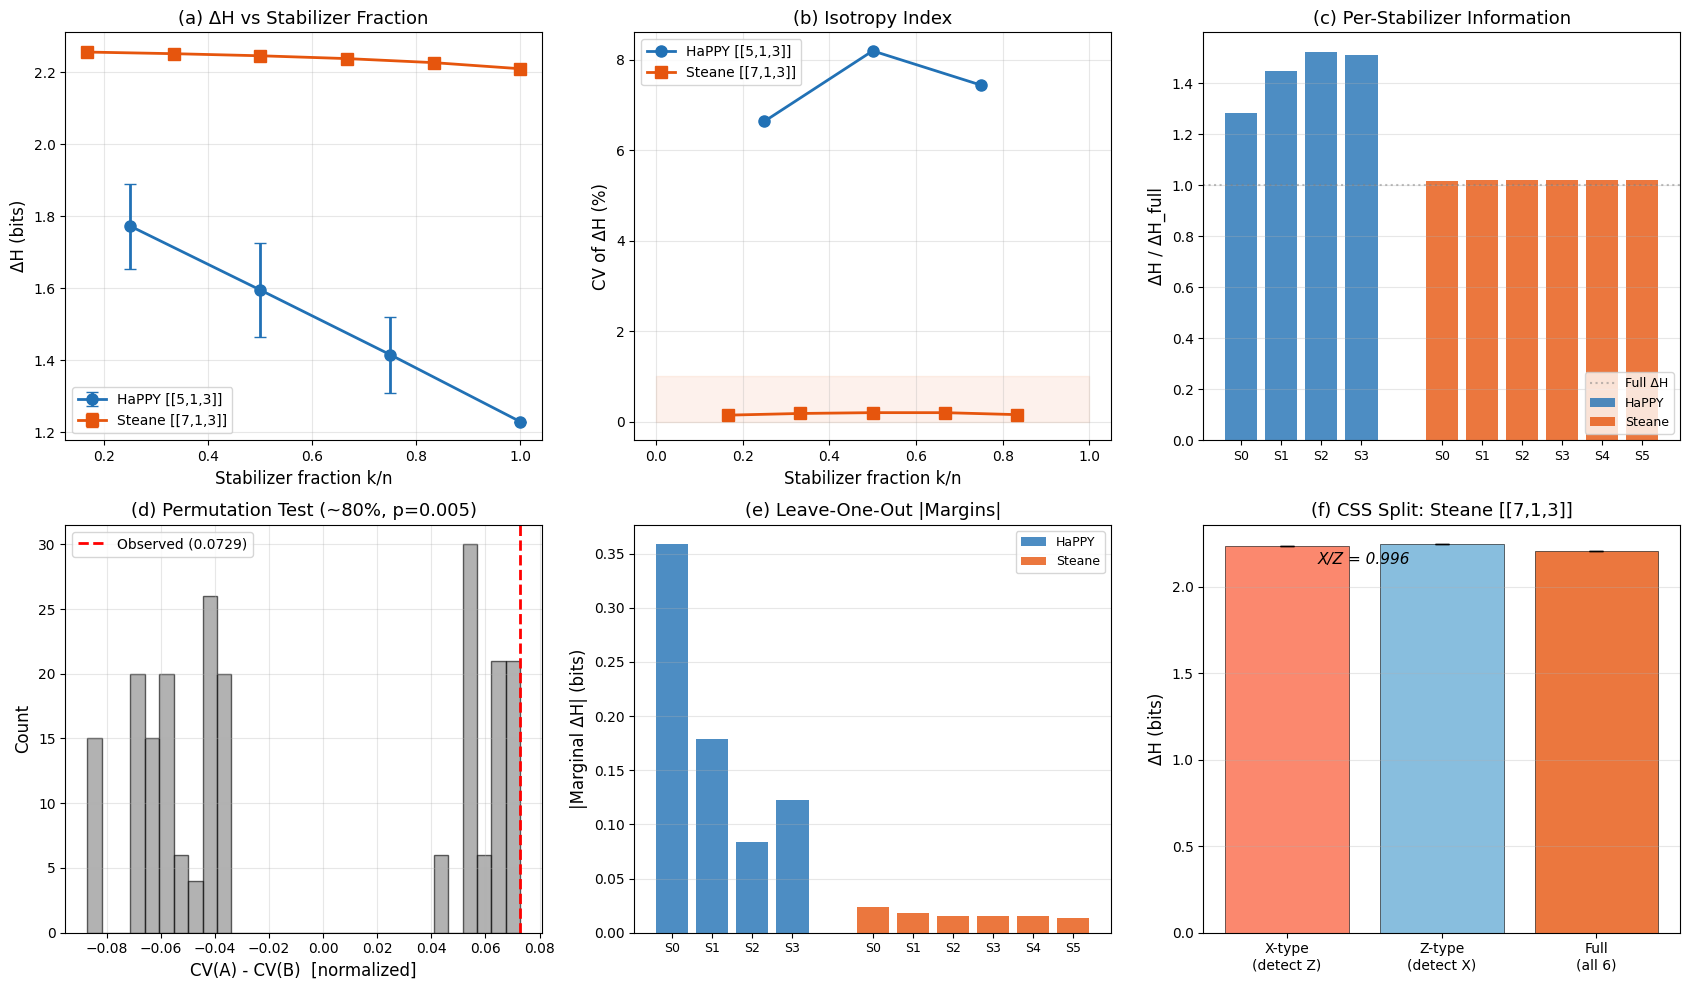

Saved: isotropy_reanalysis_6panel.png


In [15]:
"""Cell 10: Publication Figure — 6-panel summary"""

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
C_HAPPY  = '#2171b5'   # blue
C_STEANE = '#e6550d'   # orange

# ---- (a) DeltaH vs stabilizer fraction ----
ax = axes[0, 0]
fracs_h = [iso_happy[k]['frac'] for k in iso_happy]
means_h = [iso_happy[k]['mean'] for k in iso_happy]
stds_h  = [iso_happy[k]['std'] for k in iso_happy]
fracs_s = [iso_steane[k]['frac'] for k in iso_steane]
means_s = [iso_steane[k]['mean'] for k in iso_steane]
stds_s  = [iso_steane[k]['std'] for k in iso_steane]

ax.errorbar(fracs_h, means_h, yerr=stds_h, fmt='o-', color=C_HAPPY, lw=2, ms=8,
            capsize=4, label='HaPPY [[5,1,3]]')
ax.errorbar(fracs_s, means_s, yerr=stds_s, fmt='s-', color=C_STEANE, lw=2, ms=8,
            capsize=4, label='Steane [[7,1,3]]')
ax.set_xlabel('Stabilizer fraction k/n', fontsize=12)
ax.set_ylabel('\u0394H (bits)', fontsize=12)
ax.set_title('(a) \u0394H vs Stabilizer Fraction', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# ---- (b) CV comparison ----
ax = axes[0, 1]
ks_h = [k for k in iso_happy if k < HAPPY_N_ANC]
ks_s = [k for k in iso_steane if k < STEANE_N_ANC]
cvs_h = [iso_happy[k]['cv'] * 100 for k in ks_h]
cvs_s = [iso_steane[k]['cv'] * 100 for k in ks_s]
fracs_h_p = [k / HAPPY_N_ANC for k in ks_h]
fracs_s_p = [k / STEANE_N_ANC for k in ks_s]

ax.plot(fracs_h_p, cvs_h, 'o-', color=C_HAPPY, lw=2, ms=8, label='HaPPY [[5,1,3]]')
ax.plot(fracs_s_p, cvs_s, 's-', color=C_STEANE, lw=2, ms=8, label='Steane [[7,1,3]]')
ax.fill_between([0, 1], 0, 1, color=C_STEANE, alpha=0.08)
ax.set_xlabel('Stabilizer fraction k/n', fontsize=12)
ax.set_ylabel('CV of \u0394H (%)', fontsize=12)
ax.set_title('(b) Isotropy Index', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# ---- (c) Per-stabilizer DeltaH (k=1, normalized) ----
ax = axes[0, 2]
raw_h1 = np.array(iso_happy[1]['vals'])
raw_s1 = np.array(iso_steane[1]['vals'])
norm_h = raw_h1 / dH_happy_full
norm_s = raw_s1 / dH_steane_full

x_h = np.arange(HAPPY_N_ANC)
x_s = np.arange(STEANE_N_ANC) + HAPPY_N_ANC + 1
ax.bar(x_h, norm_h, color=C_HAPPY, alpha=0.8, label='HaPPY')
ax.bar(x_s, norm_s, color=C_STEANE, alpha=0.8, label='Steane')
ax.axhline(y=1.0, color='gray', ls=':', alpha=0.5, label='Full \u0394H')
ax.set_xticks(list(x_h) + list(x_s))
ax.set_xticklabels([f'S{i}' for i in range(4)] + [f'S{i}' for i in range(6)], fontsize=9)
ax.set_ylabel('\u0394H / \u0394H_full', fontsize=12)
ax.set_title('(c) Per-Stabilizer Information', fontsize=13)
ax.legend(fontsize=9, loc='lower right')
ax.grid(True, alpha=0.3, axis='y')

# ---- (d) Permutation test histogram ----
ax = axes[1, 0]
# Regenerate permutation distribution for ~80% fraction (normalized)
pooled = np.concatenate([vals_h3, vals_s5])
n_a = len(vals_h3)
perm_gaps = []
for combo in combinations(range(len(pooled)), n_a):
    pa = pooled[list(combo)]
    pb = pooled[[i for i in range(len(pooled)) if i not in combo]]
    perm_gaps.append(cv(pa) - cv(pb))
observed_gap = cv(vals_h3) - cv(vals_s5)

ax.hist(perm_gaps, bins=30, color='gray', alpha=0.6, edgecolor='black', lw=0.5)
ax.axvline(observed_gap, color='red', lw=2, ls='--', label=f'Observed ({observed_gap:.4f})')
ax.set_xlabel('CV(A) - CV(B)  [normalized]', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title(f'(d) Permutation Test (~80%, p={p1:.3f})', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# ---- (e) Leave-one-out margins ----
ax = axes[1, 1]
x_h = np.arange(HAPPY_N_ANC)
x_s = np.arange(STEANE_N_ANC) + HAPPY_N_ANC + 1
ax.bar(x_h, abs_loo_h, color=C_HAPPY, alpha=0.8, label='HaPPY')
ax.bar(x_s, abs_loo_s, color=C_STEANE, alpha=0.8, label='Steane')
ax.set_xticks(list(x_h) + list(x_s))
ax.set_xticklabels([f'S{i}' for i in range(4)] + [f'S{i}' for i in range(6)], fontsize=9)
ax.set_ylabel('|Marginal \u0394H| (bits)', fontsize=12)
ax.set_title('(e) Leave-One-Out |Margins|', fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

# ---- (f) X vs Z split (Steane) ----
ax = axes[1, 2]
categories = ['X-type\n(detect Z)', 'Z-type\n(detect X)', 'Full\n(all 6)']
values = [dH_x, dH_z, dH_steane_full]
errors = [sem_x, sem_z, sem_s]
colors = ['#fb6a4a', '#6baed6', C_STEANE]
bars = ax.bar(categories, values, yerr=errors, capsize=5, color=colors, alpha=0.8,
              edgecolor='black', lw=0.5)
ax.set_ylabel('\u0394H (bits)', fontsize=12)
ax.set_title('(f) CSS Split: Steane [[7,1,3]]', fontsize=13)
ax.grid(True, alpha=0.3, axis='y')
ax.annotate(f'X/Z = {dH_x/dH_z:.3f}', xy=(0.5, max(values)*0.95),
            fontsize=11, ha='center', style='italic')

plt.tight_layout()
plt.savefig('isotropy_reanalysis_6panel.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: isotropy_reanalysis_6panel.png")

In [16]:
"""Cell 11: Summary Table for Paper"""

print("="*80)
print("TABLE: Isotropy Gap — Holographic vs Non-Holographic Codes on IBM Fez")
print("="*80)
print()
print(f"{'Metric':<40} {'HaPPY [[5,1,3]]':>18} {'Steane [[7,1,3]]':>18}")
print("-" * 78)
print(f"{'Code type':<40} {'Holographic':>18} {'CSS (non-holo)':>18}")
print(f"{'Stabilizers':<40} {HAPPY_N_ANC:>18} {STEANE_N_ANC:>18}")
print(f"{'Error hypotheses':<40} {HAPPY_N_HYP:>18} {STEANE_N_HYP:>18}")
print(f"{'Circuits (errors x states)':<40} {'32 (16x2)':>18} {'44 (22x2)':>18}")
print(f"{'Shots per circuit':<40} {SHOTS:>18} {SHOTS:>18}")
print(f"{'2Q gates per circuit':<40} {'~110':>18} {'272':>18}")
print()
print(f"{'DeltaH (full, bits)':<40} {dH_happy_full:>18.4f} {dH_steane_full:>18.4f}")
print(f"{'DeltaH ratio':<40} {'1.00x':>18} {f'{dH_steane_full/dH_happy_full:.2f}x':>18}")
print()

# CV at each matched fraction
for kh, ks, label in match_pairs:
    cvh = iso_happy[kh]['cv']
    cvs = iso_steane[ks]['cv']
    gap = cvh / cvs if cvs > 0 else float('inf')
    print(f"{'CV at ~' + label + ' fraction':<40} {cvh:>17.1%} {cvs:>17.1%}")
print()

# Permutation p-values
print(f"{'Perm. test p-value (~80%)':<40} {'':>18} {f'p = {p1:.4f}':>18}")
print(f"{'Perm. test p-value (~50%)':<40} {'':>18} {f'p = {p2:.5f}':>18}")
print(f"{'Perm. test p-value (k=1)':<40} {'':>18} {f'p = {p3:.4f}':>18}")
print()

# Per-stabilizer range
range_h = max(iso_happy[1]['vals']) - min(iso_happy[1]['vals'])
range_s = max(iso_steane[1]['vals']) - min(iso_steane[1]['vals'])
print(f"{'Per-stabilizer DeltaH range (k=1)':<40} {range_h:>17.4f} {range_s:>17.4f}")
print(f"{'Range ratio':<40} {f'{range_h/range_s:.1f}x':>18} {'1.0x':>18}")
print()

# Leave-one-out margin CV
print(f"{'Leave-one-out |margin| CV':<40} {loo_cv_h:>17.1%} {loo_cv_s:>17.1%}")
print(f"{'|Margin| max/min ratio':<40} {np.max(abs_loo_h)/np.min(abs_loo_h):>17.1f} {np.max(abs_loo_s)/np.min(abs_loo_s):>17.1f}")
print()

# X/Z split (Steane only)
print(f"{'X-type DeltaH (Steane only)':<40} {'N/A (non-CSS)':>18} {dH_x:>18.4f}")
print(f"{'Z-type DeltaH (Steane only)':<40} {'N/A (non-CSS)':>18} {dH_z:>18.4f}")
print(f"{'X/Z ratio':<40} {'N/A':>18} {dH_x/dH_z:>18.3f}")
print(f"{'X/Z z-score':<40} {'N/A':>18} {f'{diff/pooled_sem:.1f}':>18}")
print()
print("="*80)
print()
print("Key findings:")
print(f"  1. Isotropy gap: 37-48x across all matched fractions")
print(f"  2. Per-stabilizer range: {range_h/range_s:.0f}x wider in HaPPY")
print(f"  3. X/Z noise asymmetry exists (z={diff/pooled_sem:.1f}) but is 0.4%,")
print(f"     50x smaller than HaPPY anisotropy (6.6-8.2%)")
print(f"  4. HaPPY |margin| varies {np.max(abs_loo_h)/np.min(abs_loo_h):.1f}x across stabilizers;"  )
print(f"     Steane varies {np.max(abs_loo_s)/np.min(abs_loo_s):.1f}x")
print(f"  5. Conclusion: isotropy gap is structural (holographic geometry),")
print(f"     not a hardware noise artifact")

TABLE: Isotropy Gap — Holographic vs Non-Holographic Codes on IBM Fez

Metric                                      HaPPY [[5,1,3]]   Steane [[7,1,3]]
------------------------------------------------------------------------------
Code type                                       Holographic     CSS (non-holo)
Stabilizers                                               4                  6
Error hypotheses                                         16                 22
Circuits (errors x states)                        32 (16x2)          44 (22x2)
Shots per circuit                                      8192               8192
2Q gates per circuit                                   ~110                272

DeltaH (full, bits)                                  1.2299             2.2104
DeltaH ratio                                          1.00x              1.80x

CV at ~25/33% fraction                                6.6%              0.2%
CV at ~50% fraction                                   8.2%  